## Fine Tuning the Text-to-Text Transfer Transformer for abstractive text summarization

Text-to-text framework transforms any given natural language processing task into a text generation task using prefixes without changing its objective function or architecture.


**The Brain: T5**
(Text-to-Text Transfer Transformer) is a generalist. It treats everything as a text conversion problem.
- Prefixes : Because T5 is a generalist, we have to tell it what to do using a prefix. If we just feed it an article, it won't know if we want it translated or summarized. We must add the word "summarize: " to the start of the text.

**The Fuel: CNN/DailyMail Dataset**
To teach T5 how to summarize, we need examples. The CNN/DailyMail dataset is a massive collection of news articles paired with their bullet-point highlights.
- Input (Article): "London (CNN) -- Prince Harry has arrived in..."
- Target (Highlight): "Prince Harry visits London..."

**The Language: Tokenization**
- Tokenization is chopped up text. "Apple" might become number 1045.
- Decoding is turning numbers back into text. We will use a specific tokenizer designed for T5 so we speak its language.

**Prerequisites**

In [1]:
!pip install transformers datasets torch rouge_score evaluate nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=31aff78cef3083e85db1adfa402666b29e0f979939238b3d4bfcf5d8b82766c5
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


**Dependencies**

In [2]:
import numpy as np # numerical computing and array operations
import pandas as pd # data manipulation and analysis

# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # To count word frequencies
from wordcloud import WordCloud, STOPWORDS

import torch # DL Framework
import nltk # Natural Language Toolkit
import evaluate # Hugging Face library to load and calculate evaluation metrics
from datasets import load_dataset # download and load dataset from the HF Hub
from transformers import (
    # tokenizer for T5
    T5Tokenizer, #  converts raw text into input IDs the model can understand
    T5ForConditionalGeneration, # T5 model architecture for text-to-text tasks
    Seq2SeqTrainingArguments, # hyperparameters for sequence-to-sequence train
    Seq2SeqTrainer, # handles the training loop, evaluation, and optimization
    DataCollatorForSeq2Seq # pads inputs and labels to the maximum length
)
from tqdm.auto import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

**Configuration & Setup**

In [3]:
DATASET_NAME = "cnn_dailymail"
DATASET_VERSION = "3.0.0" # the standard
MODEL_NAME = "t5-base"
OUTPUT_DIR = "./t5_results"

# for metric calculation
nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Data Loading & Preparation**

In [4]:
# Newspaper Text Summarization (CNN DailyMail) Dataset
print(f"Loading {DATASET_NAME} dataset...")
dataset = load_dataset(DATASET_NAME, DATASET_VERSION)

# Example
print(f"Article: {dataset['train'][0]['article'][:100]}...") # First 100 chars
print(f"Summary: {dataset['train'][0]['highlights']}")

Loading cnn_dailymail dataset...


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Article: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 milli...
Summary: Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


**Columns are :**
- article: The input text (news article).
- highlights: The target summary.

In [5]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(10000))
val_dataset = dataset["validation"].shuffle(seed=42).select(range(5000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(5000))

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 10000
Validation size: 5000
Test size: 5000


In [6]:
train_df_sample = load_dataset("cnn_dailymail", "3.0.0", split="train[:1%]")
df = train_df_sample.to_pandas()

# Lengths (word count)
df['article_len'] = df['article'].apply(lambda x: len(x.split()))
df['highlight_len'] = df['highlights'].apply(lambda x: len(x.split()))
print("Article Length Distribution : \n", df['article_len'], "\n")
print("Highlight Length Distribution : \n", df['highlight_len'])

Article Length Distribution : 
 0        455
1        698
2        743
3        414
4        973
        ... 
2866     240
2867     390
2868    1011
2869     833
2870     524
Name: article_len, Length: 2871, dtype: int64 

Highlight Length Distribution : 
 0       41
1       49
2       43
3       27
4       44
        ..
2866    40
2867    35
2868    45
2869    49
2870    30
Name: highlight_len, Length: 2871, dtype: int64


In [7]:
df.article

,article
0,"LONDON, England (Reuters) -- Harry Potter star..."
1,Editor's note: In our Behind the Scenes series...
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we..."
3,WASHINGTON (CNN) -- Doctors removed five small...
4,(CNN) -- The National Football League has ind...
...,...
2866,"LONDON, England (CNN) -- David Prowse, who pla..."
2867,"MOGADISHU, Somalia (CNN) -- Gunmen attacked a..."
2868,"(CNN) -- She's being hailed as the ""face of th..."
2869,"Editor's note: Frances Fragos Townsend, a CNN ..."


In [8]:
df.highlights

,highlights
0,Harry Potter star Daniel Radcliffe gets £20M f...
1,Mentally ill inmates in Miami are housed on th...
2,"NEW: ""I thought I was going to die,"" driver sa..."
3,"Five small polyps found during procedure; ""non..."
4,"NEW: NFL chief, Atlanta Falcons owner critical..."
...,...
2866,"David Prowse, who played Darth Vader in ""Star ..."
2867,"Gunman seized convoy in southwestern Somalia, ..."
2868,President Obama discussed economy in hard-hit ...
2869,Frances Townsend: Leon Panetta has had a fine ...


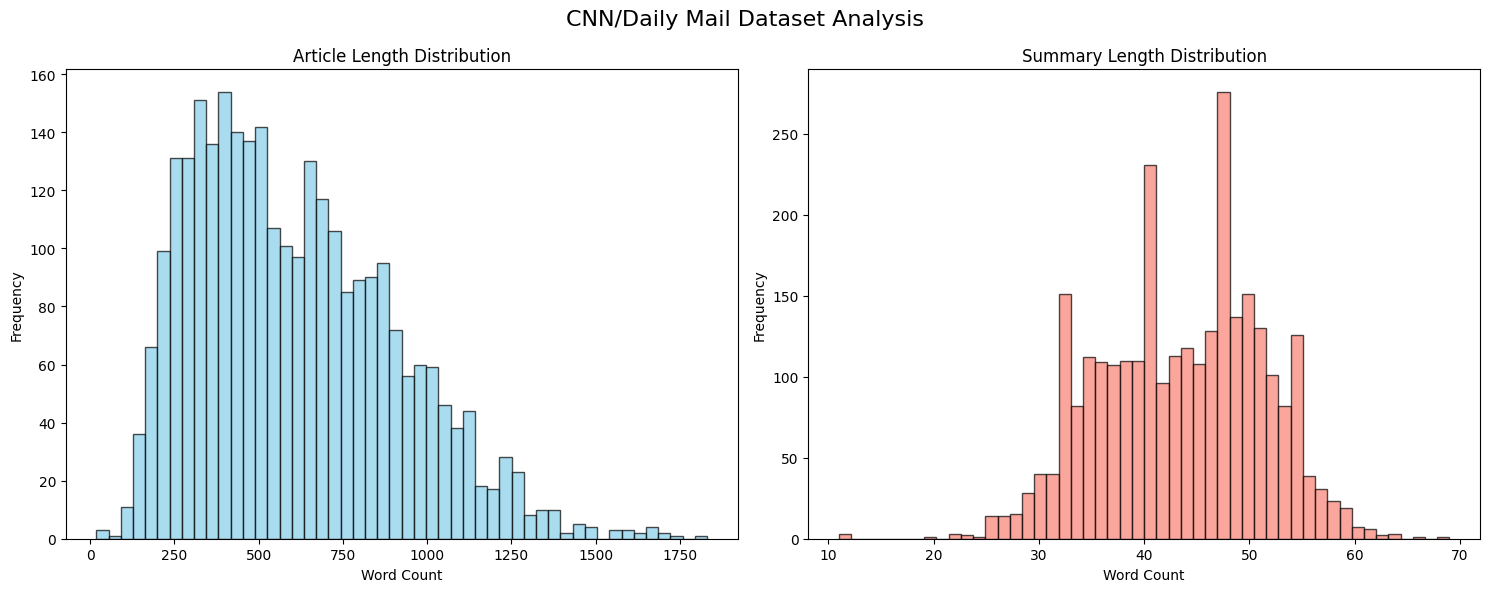

In [9]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df['article_len'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Article Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['highlight_len'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Summary Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.suptitle('CNN/Daily Mail Dataset Analysis', fontsize=16)
plt.tight_layout()

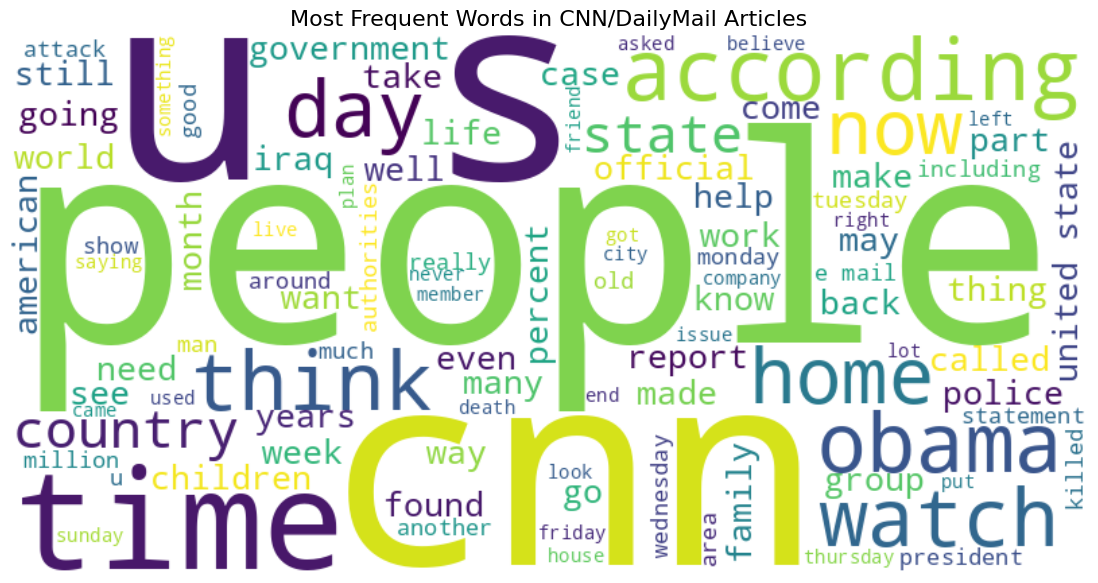

In [10]:
text = " ".join(article for article in df.article).lower()
stopwords = set(STOPWORDS)
stopwords.update(["say", "says", "said", "said.", "said,", "will", "one", "also", "new", "year", "tell", "told", "\"the", "\"we", "first", "last", "two", "three"]) # journalistic style words

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    max_words=100
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in CNN/DailyMail Articles", fontsize=16)
plt.show()

In [11]:
words = text.split()
filtered_words = [word for word in words if word not in stopwords and len(word) > 2]

In [12]:
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(25)
df_words = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

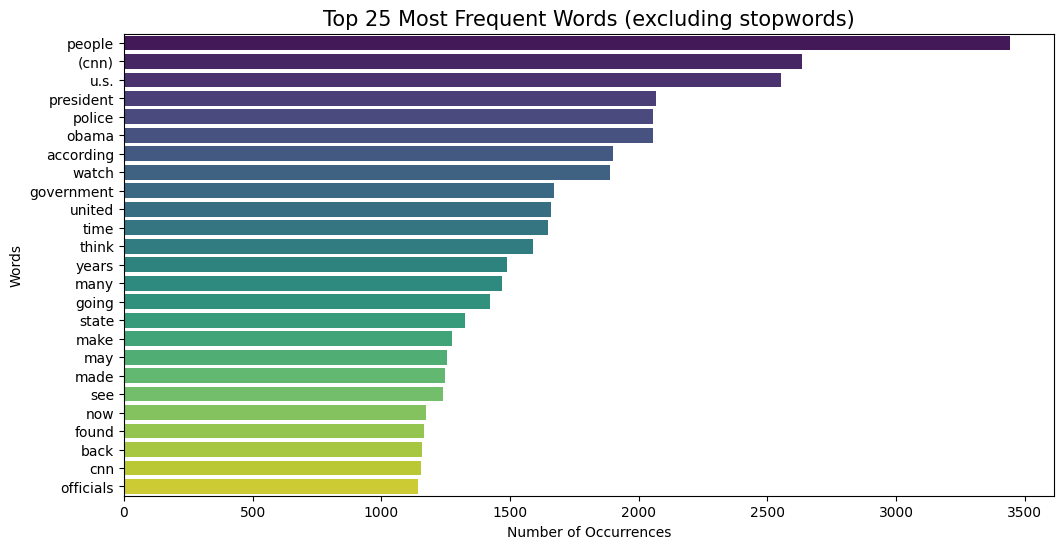

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Word', data=df_words, palette='viridis')
plt.title('Top 25 Most Frequent Words (excluding stopwords)', fontsize=15)
plt.xlabel('Number of Occurrences')
plt.ylabel('Words')
plt.show()

**Data Pre-processing**

We need to do two things :
- Add the "summarize: " prefix to every article.
- Turn words into numbers **(Tokenization).**

In [14]:
print("Loading Tokenizer...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

Loading Tokenizer...


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [15]:
MAX_INPUT_LENGTH = 512  # Max length for the article
MAX_TARGET_LENGTH = 128  # Max length for the summary

In [16]:
def preprocess(examples):
    inputs = ["summarize: " + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=MAX_INPUT_LENGTH, truncation=True)
    labels = tokenizer(text_target=examples["highlights"], max_length=MAX_TARGET_LENGTH, truncation=True)
    model_inputs["labels"] = labels["input_ids"] # labels["input_ids"] : IDs du résumé
    return model_inputs

In [17]:
print("Preprocessing data...")
tokenized_train = train_dataset.map(preprocess, batched=True)
tokenized_val = val_dataset.map(preprocess, batched=True)
tokenized_test = test_dataset.map(preprocess, batched=True)

Preprocessing data...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

#### T5 transformer Model and Metrics

**Loading the Pre-trained Model from Hugging Face**

The model is loaded directly from the Hugging Face hub with the learned weights.

In [18]:
BATCH_SIZE = 6
EPOCHS = 5

In [19]:
print("Initializing Model...")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME) # architecture + weights
"""
data_collator :
- assembles the data into "batches" during training.
- adds padding so that all sequences in the same batch have the same length.
"""
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

"""
rouge :
- the standard for evaluating the quality of summaries.
- it measures the overlap of words between the generated summary and the reference summary.
"""
rouge = evaluate.load("rouge") # ROUGE metric

Initializing Model...


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

**Evaluation function (ROUGE)**

In [20]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = ["\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels]

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    result = {key: value * 100 for key, value in result.items()}
    return {k: round(v, 4) for k, v in result.items()}

**Training Arguments & Trainer**

In [21]:
# Hyperparameters
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5-summarizer",
    learning_rate=1e-5, # to preserve learned representations
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    predict_with_generate=True,
    gradient_accumulation_steps=16,
    logging_steps=50,
    # regularization (penalty) during training to prevent the model weights from becoming too large, which helps to avoid overfitting
    weight_decay=0.01,
    num_train_epochs=EPOCHS,
    fp16=True,  # reduces memory consumption on GPU
    dataloader_num_workers=2,# Uses 2 CPU subprocesses to load and prepare data in parallel, thus preventing the GPU from remaining idle while waiting for data
    eval_strategy="epoch",
    save_strategy="epoch",
)

# AdamW optimizer is chosen by default to optimize the model and avoid catastrophic forgetting of the learned representations.
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

**Training and Saving the Model**

In [22]:
# Fine tuning phase
tqdm.write("Starting Training...")
with tqdm(total=2, desc="Overall Pipeline") as pbar:
    pbar.set_description("Training Model")
    start_time = time.time()
    train_result = trainer.train()
    end_time = time.time()
    pbar.update(1)

    print("Saving model...")
    pbar.set_description("Saving Checkpoints")
    trainer.save_model("./t5_model")
    tokenizer.save_pretrained("./t5_tokenizer")

    pbar.update(1)
    pbar.set_description("Done")

tqdm.write("Training Complete!")

Starting Training...


Overall Pipeline:   0%|          | 0/2 [00:00<?, ?it/s]

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.011000,1.742142,25.200800,12.225300,20.611800,23.681400
2,1.696800,1.580342,25.304500,12.279700,20.719700,23.813400


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.011000,1.742142,25.200800,12.225300,20.611800,23.681400
2,1.696800,1.580342,25.304500,12.279700,20.719700,23.813400
3,1.717200,1.569802,25.280500,12.205600,20.681500,23.781800
4,1.697300,1.570187,25.265400,12.198200,20.668200,23.764700
5,1.703900,1.570382,25.258000,12.190100,20.660500,23.762600


Saving model...
Training Complete!


In [23]:
# time metrics
metrics = train_result.metrics
total_time = metrics['train_runtime']  # In seconds
n_epochs = training_args.num_train_epochs
time_per_epoch = total_time / n_epochs

print(f"Total training time: {total_time:.2f} seconds")
print(f"Average time per epoch: {time_per_epoch:.2f} seconds")

Total training time: 7581.16 seconds
Average time per epoch: 1516.23 seconds


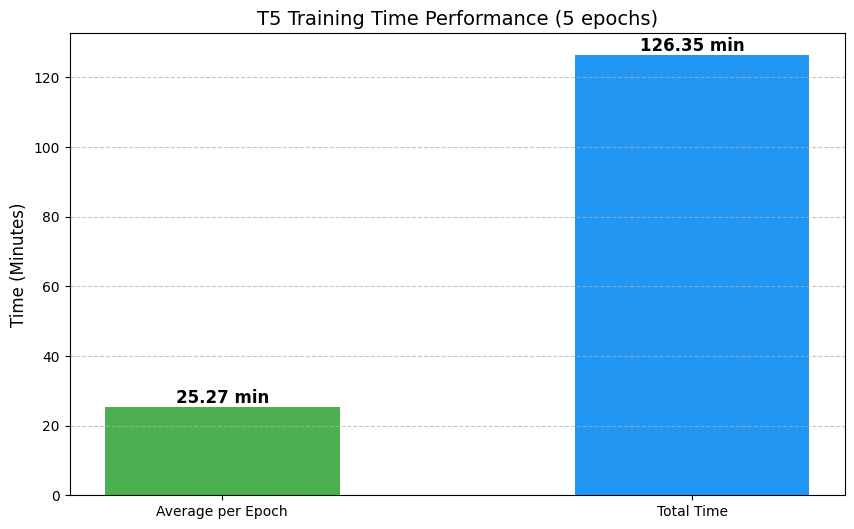

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
times = [time_per_epoch / 60, total_time / 60]  # Convert to minutes
labels = ['Average per Epoch', 'Total Time']
bars = ax.bar(labels, times, color=['#4CAF50', '#2196F3'], width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f} min',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Time (Minutes)', fontsize=12)
ax.set_title(f'T5 Training Time Performance ({n_epochs} epochs)', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

In [25]:
trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)

***** train metrics *****
  epoch                    =        5.0
  total_flos               = 28356811GF
  train_loss               =     1.7751
  train_runtime            = 2:06:21.16
  train_samples_per_second =      6.595
  train_steps_per_second   =      0.069


**Evaluation**

In [26]:
history = trainer.state.log_history

In [27]:
# recorded every 'logging_steps'
train_loss = [x['loss'] for x in history if 'loss' in x]
train_epochs = [x['epoch'] for x in history if 'loss' in x]

In [28]:
# Validation Loss (recorded at each evaluation strategy interval)
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_epochs = [x['epoch'] for x in history if 'eval_loss' in x]

In [29]:
rouge1 = [x['eval_rouge1'] for x in history if 'eval_rouge1' in x]
rouge2 = [x['eval_rouge2'] for x in history if 'eval_rouge2' in x]
rougeL = [x['eval_rougeL'] for x in history if 'eval_rougeL' in x]
rougeLsum = [x['eval_rougeLsum'] for x in history if 'eval_rougeLsum' in x]
rouge_epochs = [x['epoch'] for x in history if 'eval_rouge1' in x]

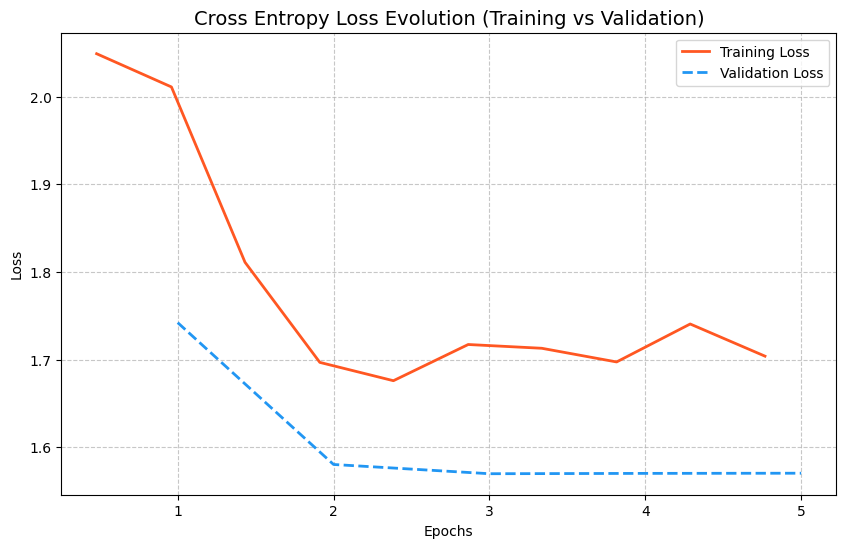

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(train_epochs, train_loss, label='Training Loss', color='#FF5722', linewidth=2)
plt.plot(eval_epochs, eval_loss, label='Validation Loss', color='#2196F3', linewidth=2, linestyle='--')

plt.title('Cross Entropy Loss Evolution (Training vs Validation)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

In [31]:
if eval_loss:
    print(f"Final Validation Loss: {eval_loss[-1]:.4f}")

Final Validation Loss: 1.5704


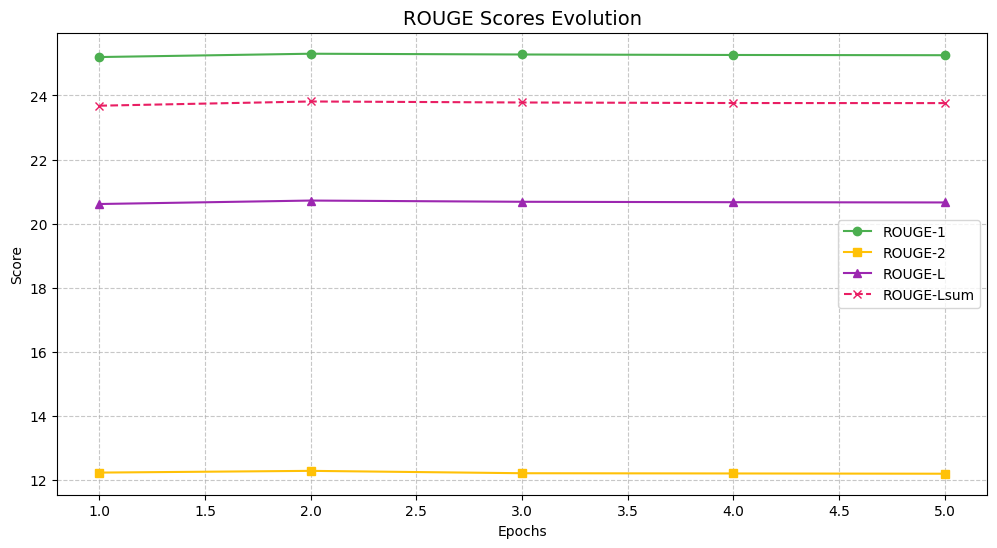

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

# ROUGE Scores
ax.plot(rouge_epochs, rouge1, label='ROUGE-1', color='#4CAF50', marker='o')
ax.plot(rouge_epochs, rouge2, label='ROUGE-2', color='#FFC107', marker='s')
ax.plot(rouge_epochs, rougeL, label='ROUGE-L', color='#9C27B0', marker='^')
ax.plot(rouge_epochs, rougeLsum, label='ROUGE-Lsum', color='#E91E63', marker='x', linestyle='--')
ax.set_title('ROUGE Scores Evolution', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

In [33]:
print(f"Final ROUGE-1: {rouge1[-1]:.2f}")
print(f"Final ROUGE-2: {rouge2[-1]:.2f}")
print(f"Final ROUGE-L: {rougeL[-1]:.2f}")
print(f"Final ROUGE-Lsum: {rougeLsum[-1]:.2f}")

Final ROUGE-1: 25.26
Final ROUGE-2: 12.19
Final ROUGE-L: 20.66
Final ROUGE-Lsum: 23.76


In [34]:
trainer.args.predict_with_generate = True
final_metrics = trainer.evaluate()

print(f"📉 Validation Loss : {final_metrics['eval_loss']:.4f}")
print(f"⌛ Runtime : {final_metrics['eval_runtime']:.2f}s")
print(f"ROUGE-1         : {final_metrics['eval_rouge1']:.2f}")
print(f"ROUGE-2         : {final_metrics['eval_rouge2']:.2f}")
print(f"ROUGE-L         : {final_metrics['eval_rougeL']:.2f}")
print(f"ROUGE-Lsum      : {final_metrics['eval_rougeLsum']:.2f}")

df_scores = pd.DataFrame([final_metrics])
cols_to_keep = ['eval_loss', 'eval_rouge1', 'eval_rouge2', 'eval_rougeL', 'eval_rougeLsum', 'eval_runtime']
cols_existing = [c for c in cols_to_keep if c in df_scores.columns]
display(df_scores[cols_existing])

📉 Validation Loss : 1.5704
⌛ Runtime : 786.89s
ROUGE-1         : 25.26
ROUGE-2         : 12.19
ROUGE-L         : 20.66
ROUGE-Lsum      : 23.76


,eval_loss,eval_rouge1,eval_rouge2,eval_rougeL,eval_rougeLsum,eval_runtime
0,1.570382,25.258,12.1901,20.6605,23.7626,786.8937


In [39]:
print("Generating summaries for visual analysis...")
small_test_dataset = tokenized_test.select(range(50))
predictions, labels, _ = trainer.predict(small_test_dataset)

print("Decoding texts...")
decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
decoded_inputs = tokenizer.batch_decode(small_test_dataset['input_ids'], skip_special_tokens=True)

df_results = pd.DataFrame({
    'Article': [text.replace('summarize: ', '') for text in decoded_inputs],
    'Reference': decoded_labels,
    'Generated': decoded_preds
})

df_results['Ref_Len'] = df_results['Reference'].apply(lambda x: len(x.split()))
df_results['Gen_Len'] = df_results['Generated'].apply(lambda x: len(x.split()))
df_results['Article_Len'] = df_results['Article'].apply(lambda x: len(x.split()))

Generating summaries for visual analysis...


Decoding texts...


In [40]:
df_results.head()

,Article,Reference,Generated,Ref_Len,Gen_Len,Article_Len
0,"(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data showing just how helpful it can be. I see a revolution in the attitudes of everyday Americans. For the first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes. Support for legalization has risen 11 points in the past few years alone. In 1969, the first time Pew asked the question about legalization, only 12% of the nation was in favor. I see a revolution that is burning white hot among young people, but also shows up among the parents and grandparents in my kids' school. A police officer I met in Michigan is part of the revolution, as are the editors of the medical journal, Neurosurgery. I see it in the faces of good parents, uprooting their lives to get medicine for their children -- and in the children themselves, such as Charlotte, who went from having 300 seizures a week to just one or two a month. We know it won't consistently have such dramatic results (or any impact at all) in others, but what medicine does? I see this medical marijuana revolution in surprising places. Girl's seizures spur medical marijuana legislation in Georgia . Among my colleagues, my patients and my friends. I have even seen the revolution in my own family. A few years ago, when I told my mother I was investigating the topic for a documentary, I was met with a long pause. ""Marijuana...?"" She whispered in a half questioning, half disapproving tone. She could barely even say the word and her response filled me with self-doubt. Even as a grown man, mom can still make my cheeks turn red and shatter my confidence with a single word. But just last week she suddenly stopped mid-conversation and said, ""I am proud of you on the whole marijuana thing."" I","CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now . He says he knows how easy it is do nothing ""because I did nothing for too long""","a majority of Americans favor medical marijuana legalization, says adam scott .",29,12,393
1,"He looks barely teenage. But this child has amassed thousands of Twitter followers with his pictorial updates of 'gang life'. The baby-faced boy from Memphis, Tennessee, poses with guns, cash, and bags of what looks like marijuana. Scroll down for video . Baby-faced: This little boy has amassed more than 3,000 followers on Twitter with pictures like these . In many pictures he is smoking suspicious substances, with captions such as 'High Life' Backlash: The boy, from Memphis, has prompted a wave of critics calling his stunts 'sad' In one video he laughs and points the gun at the camera in an apparent attempt to look menacing - as adults laugh in the background. In others, he is pictured blowing smoke, with the caption: 'High Life'. Tweets include the phrases, 'I need a bad b****', 'f*** da police', and 'gang sh** n****'. Some feature sexual references, such as: 'quit suckin my d***'. As he is a minor, DailyMail.com will not identify the little boy. The child's tweets have prompted backlash from other Twitter users and members of the community. One woman tweeted him: 'you need help i feel so bad for you your parents should be ashamed please get help and a education this is sad and disappointing.' Another Twitter user said: 'You poor baby. Just stop it & go to school.' Adults around: Many of his pictures and videos are taken with adults who are seen laughing, unfazed . Guns: The little boy, who appears to be barely teenage, regularly poses for his followers with guns . Th

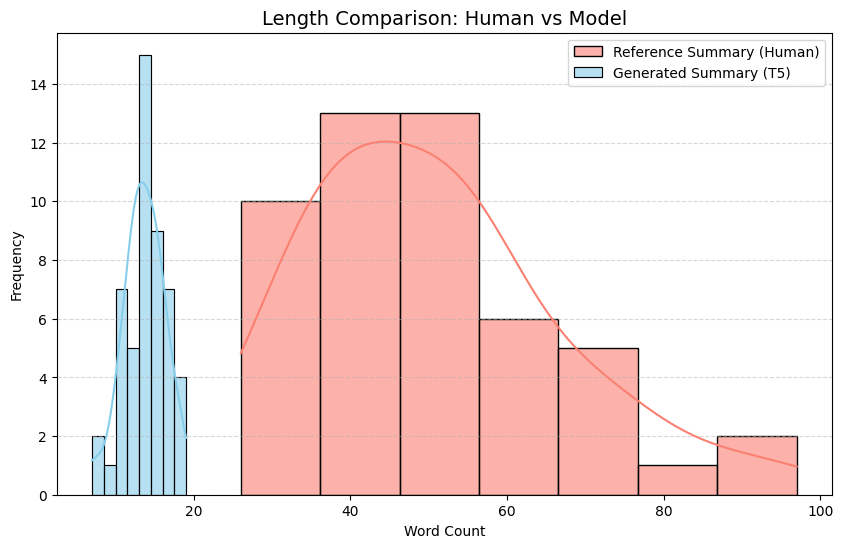

In [41]:
plt.figure(figsize=(10, 6))

sns.histplot(df_results['Ref_Len'], color='salmon', label='Reference Summary (Human)', kde=True, alpha=0.6)
sns.histplot(df_results['Gen_Len'], color='skyblue', label='Generated Summary (T5)', kde=True, alpha=0.6)

plt.title('Length Comparison: Human vs Model', fontsize=14)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [42]:
pd.set_option('display.max_colwidth', None)

display(df_results[['Article', 'Reference', 'Generated']].sample(3))

df_results.to_csv("t5_predictions_analysis.csv", index=False)
print("Table saved to 't5_predictions_analysis.csv'")

,Article,Reference,Generated
29,"Floyd Mayweather Jnr's personal chef responsible for fuelling the the fighter ahead of his $300million clash with Manny Pacquiao has revealed her boss does have some weaknesses when it comes to food. Quiana Jeffries, aka Chef Q, was brought into Mayweather's camp after driving through the night to impress him with a trial breakfast. A regimented diet is crucial to the champion's training regime and Mayweather demands organic produce, although there are a few exceptions. 'Twizzlers are his favorite,' Jeffries reveals in an interview with New York Magazine. Floyd Mayweather Jnr (left) insists on eating organic food before his fight, although there are exceptions . Chef Q has been cooking for Mayweather since his fight for Manny Pacquaio was announced . Fried turkey dogs are specialty southern dish of Chef Q's that Mayweather loves to indulge on . This steak dished was cooked by Chef Q and would have cost the boxer $1,000 per plate . Quiana Jeffries has helped the champ with his strict organic food diet, but has problems getting ingredients . Who do you think WILL win the fight between Floyd Mayweather and Manny Pacquiao? Who do you think WILL win the fight between Floyd Mayweather and Manny Pacquiao? Now share your opinion . 'And Top Ramen (dried noodle packets). 'It's what he had growing up. He likes them crunchy, with a lot of noodles, and not a lot of juice,' she adds. However, Mayweather's most unhealthy food craving has got to be 'fried hot dogs... with barbecue sauce'. Jeffries explains that she tries her best to ake them as healthy as possible: 'I cut them longways, and fry them up in a little coconut oil. I spice that up the barbeque sauce, too. 'I add a oranges, orange zest, and other spices. He loves barbecue sauce. Everything with barbecue sauce. But that's life. You like what you know.' As well as unusual eating requests, Jeffries also has to cope with Mayweather's unconventional timekeeping. The 38-year-old does not followed a structured training regime and prefers to decide when he does things according to how he","Floyd Mayweather meets Manny Pacquiao in Las Vegas on May 2 . Chef Q Quiana Jeffries prepares US boxer's food using organic produce . She says champ has a soft spots for Twizzlers, noodles and fried hotdogs .","Quiana Jeffries, aka Chef Q, has been cooking for Floyd Mayweather since his fight"
38,"Ed Miliband today rushed to Scotland to try to shore up his hope of becoming Prime Minister as a damning poll showed almost half of Scots are ready to back the SNP. The Labour leader used a speech in Edinburgh to claim the Tory election campaign has descended into 'desperation and panic', as some polls put Labour ahead across the UK. But Mr Miliband has been rocked by a survey showing that in Scotland, 49 per cent of people plan to vote for the SNP, with just 25 per cent backing Labour, robbing him of any possibility of an overall majority. Scroll down for video . A poll of Scotlans shows 49 per cent of people plan to vote for the SNP, with just 25 per cent backing Labour . There has been a surge in support for the SNP in the months since the independence referendum in September . In September's referendum, 55 per cent voted in favour of staying in the UK, but the SNP has seen a surge in support since then and is set to take dozens of seats from Labour in the general election on May 7. The new YouGov poll for The Times shows Labour is down four points on last month to their lowest level since the survey began in 2007. The SNP is up three points to 49 per cent, a record high. Support for the Conservatives was up two points at 18 per cent and backing for the Liberal Democrats was up one point at 4 per cent. The results have delighted First Minister Nicola Sturgeon, who insisted she is taking 'absolutely nothing for granted'. 'The polls are hugely encouraging and they show that that case that the SNP is putting forward for an end to austerity and support for the NHS and public serv

Table saved to 't5_predictions_analysis.csv'
